In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.over_sampling import RandomOverSampler
from scipy.sparse import csr_matrix, save_npz
from scipy.stats import randint, uniform
import pickle
import warnings
import gc

warnings.filterwarnings('ignore')

In [2]:
# =============================================================
# CONFIG
# =============================================================
K_FOLDS = 5
NEG_TRAIN_SIZE = 1000       # negative patients per training fold
TOP_N = 50
RANDOM_STATE = 42
SMOTE_K_NEIGHBORS = 5       # unused w/ RandomOverSampler, kept for easy swap back
OVERSAMPLER = 'random'      # 'random' or 'smoteenn'

rng = np.random.RandomState(RANDOM_STATE)

In [3]:
# =============================================================
# LOAD DATA
# =============================================================
df = pd.read_parquet(r"MODEL_READY_MATRIX_NAMED_LABS.parquet")

print(f"Loaded matrix: {df.shape}")
print(f"  Label=1 (AD): {(df['LABEL']==1).sum()}")
print(f"  Label=0 (Control): {(df['LABEL']==0).sum()}")

feature_cols = [c for c in df.columns if c not in ['SUBJECT_ID', 'LABEL']]

pos_df = df[df['LABEL'] == 1].reset_index(drop=True)
neg_df = df[df['LABEL'] == 0].reset_index(drop=True)

n_pos = len(pos_df)
n_neg = len(neg_df)
print(f"\nPositive patients: {n_pos}")
print(f"Negative patients: {n_neg}")
print(f"Features: {len(feature_cols)}")

Loaded matrix: (46249, 6709)
  Label=1 (AD): 76
  Label=0 (Control): 46173

Positive patients: 76
Negative patients: 46173
Features: 6707


In [4]:
# =============================================================
# BUILD CUSTOM FOLDS w/ SMOTE-ENN
# =============================================================
pos_indices = rng.permutation(n_pos)
pos_folds = np.array_split(pos_indices, K_FOLDS)

print(f"\nPositive fold sizes: {[len(f) for f in pos_folds]}")
print(f"Negative training size per fold: {NEG_TRAIN_SIZE}")
print(f"Oversampling method: SMOTE-ENN (k_neighbors={SMOTE_K_NEIGHBORS})")

folds = []
for i in range(K_FOLDS):
    print(f"\n--- Building fold {i} ---")

    # positive test = fold i, positive train = everything else
    pos_test_idx = pos_folds[i]
    pos_train_idx = np.concatenate([pos_folds[j] for j in range(K_FOLDS) if j != i])

    # sample negatives for training, rest for test
    neg_train_idx = rng.choice(n_neg, size=NEG_TRAIN_SIZE, replace=False)
    neg_test_idx = np.setdiff1d(np.arange(n_neg), neg_train_idx)

    # assemble raw (pre-resampling) training set
    train_pos = pos_df.iloc[pos_train_idx]
    train_neg = neg_df.iloc[neg_train_idx]
    train_raw = pd.concat([train_pos, train_neg], ignore_index=True)

    X_train_raw = train_raw[feature_cols].values.astype(np.float32)
    y_train_raw = train_raw['LABEL'].values

    print(f"  pre-resample:  {len(y_train_raw)} samples "
          f"(pos={y_train_raw.sum()}, neg={len(y_train_raw)-y_train_raw.sum()})")

    # oversample minority class
    ros = RandomOverSampler(random_state=RANDOM_STATE + i)
    X_train_resampled, y_train_resampled = ros.fit_resample(
        X_train_raw, y_train_raw
    )

    print(f"  post-resample: {len(y_train_resampled)} samples "
          f"(pos={y_train_resampled.sum()}, neg={len(y_train_resampled)-y_train_resampled.sum()})")

    # assemble test set
    test_pos = pos_df.iloc[pos_test_idx]
    test_neg = neg_df.iloc[neg_test_idx]
    test = pd.concat([test_pos, test_neg], ignore_index=True)
    test = test.sample(frac=1, random_state=RANDOM_STATE + i).reset_index(drop=True)

    X_te = test[feature_cols].values.astype(np.float32)
    y_te = test['LABEL'].values

    # shuffle training
    shuffle_idx = rng.permutation(len(y_train_resampled))
    X_train_resampled = X_train_resampled[shuffle_idx]
    y_train_resampled = y_train_resampled[shuffle_idx]

    folds.append({
        'X_train': csr_matrix(X_train_resampled),
        'y_train': y_train_resampled,
        'X_test': csr_matrix(X_te),
        'y_test': y_te,
    })

    print(f"  test: {len(y_te)} (pos={y_te.sum()}, neg={len(y_te)-y_te.sum()})")

    del X_train_raw, y_train_raw, X_train_resampled, y_train_resampled, X_te
    gc.collect()


Positive fold sizes: [16, 15, 15, 15, 15]
Negative training size per fold: 1000
Oversampling method: SMOTE-ENN (k_neighbors=5)

--- Building fold 0 ---
  pre-resample:  1060 samples (pos=60, neg=1000)
  post-resample: 2000 samples (pos=1000, neg=1000)
  test: 45189 (pos=16, neg=45173)

--- Building fold 1 ---
  pre-resample:  1061 samples (pos=61, neg=1000)
  post-resample: 2000 samples (pos=1000, neg=1000)
  test: 45188 (pos=15, neg=45173)

--- Building fold 2 ---
  pre-resample:  1061 samples (pos=61, neg=1000)
  post-resample: 2000 samples (pos=1000, neg=1000)
  test: 45188 (pos=15, neg=45173)

--- Building fold 3 ---
  pre-resample:  1061 samples (pos=61, neg=1000)
  post-resample: 2000 samples (pos=1000, neg=1000)
  test: 45188 (pos=15, neg=45173)

--- Building fold 4 ---
  pre-resample:  1061 samples (pos=61, neg=1000)
  post-resample: 2000 samples (pos=1000, neg=1000)
  test: 45188 (pos=15, neg=45173)


In [5]:
# =============================================================
# HELPER: collect metrics
# =============================================================
METRIC_NAMES = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

def find_optimal_threshold(y_true, y_prob, method='youden'):
    """
    Find optimal classification threshold on training data.
    
    methods:
        'youden'  — maximize sensitivity + specificity - 1 (standard clinical screening)
        'f1'      — maximize F1 score
        'f2'      — maximize F2 score (weights recall 2x over precision)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    
    if method == 'youden':
        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
    elif method == 'f1':
        f1s = []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            f1s.append(f1_score(y_true, preds, zero_division=0))
        best_idx = np.argmax(f1s)
    elif method == 'f2':
        from sklearn.metrics import fbeta_score
        f2s = []
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            f2s.append(fbeta_score(y_true, preds, beta=2, zero_division=0))
        best_idx = np.argmax(f2s)
    else:
        raise ValueError(f"unknown method: {method}")
    
    return thresholds[best_idx]


def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

def print_cv_results(name, all_metrics):
    print(f"\n{name} Results (mean +/- std across folds):")
    for m in METRIC_NAMES:
        vals = np.array([d[m] for d in all_metrics])
        print(f"  {m}: {vals.mean():.4f} +/- {vals.std():.4f}")

In [6]:
# =============================================================
# DECISION TREE
# =============================================================
print("\n" + "=" * 60)
print("DECISION TREE")
print("=" * 60)

dt_metrics = []
dt_importances_list = []
dt_estimators = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    dt = DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
    dt.fit(fold['X_train'], fold['y_train'])

    y_pred = dt.predict(fold['X_test'])
    y_prob = dt.predict_proba(fold['X_test'])[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    dt_metrics.append(m)
    dt_importances_list.append(dt.feature_importances_)
    dt_estimators.append(dt)
    print(f"AUC: {m['roc_auc']:.4f}")

print_cv_results("Decision Tree", dt_metrics)

dt_importances = np.mean(dt_importances_list, axis=0)
dt_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_importances
}).sort_values('importance', ascending=False)
print(f"Non-zero importance features: {(dt_importances > 0).sum()}")


DECISION TREE
  Fold 1/5... AUC: 0.7067
  Fold 2/5... AUC: 0.6374
  Fold 3/5... AUC: 0.7368
  Fold 4/5... AUC: 0.6324
  Fold 5/5... AUC: 0.6980

Decision Tree Results (mean +/- std across folds):
  accuracy: 0.8348 +/- 0.0256
  f1: 0.0020 +/- 0.0004
  precision: 0.0010 +/- 0.0002
  recall: 0.4867 +/- 0.0777
  roc_auc: 0.6823 +/- 0.0408
Non-zero importance features: 73


In [7]:
# =============================================================
# LASSO (L1 LOGISTIC REGRESSION)
# =============================================================
print("\n" + "=" * 60)
print("LASSO (L1 LOGISTIC REGRESSION)")
print("=" * 60)

lasso_metrics = []
lasso_coefs_list = []
lasso_estimators = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")

    scaler = StandardScaler(with_mean=False)
    X_tr_scaled = scaler.fit_transform(fold['X_train'])
    X_te_scaled = scaler.transform(fold['X_test'])

    lasso = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=5000,
        C=1.0,
        random_state=RANDOM_STATE,
    )
    lasso.fit(X_tr_scaled, fold['y_train'])

    y_pred = lasso.predict(X_te_scaled)
    y_prob = lasso.predict_proba(X_te_scaled)[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    lasso_metrics.append(m)
    lasso_coefs_list.append(np.abs(lasso.coef_[0]))
    lasso_estimators.append((lasso, scaler))
    print(f"AUC: {m['roc_auc']:.4f}")

    del X_tr_scaled, X_te_scaled
    gc.collect()

print_cv_results("Lasso", lasso_metrics)

lasso_coefs = np.mean(lasso_coefs_list, axis=0)
lasso_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lasso_coefs
}).sort_values('importance', ascending=False)
print(f"Non-zero coefficient features: {(lasso_coefs > 0).sum()}")


LASSO (L1 LOGISTIC REGRESSION)
  Fold 1/5... AUC: 0.7342
  Fold 2/5... AUC: 0.7615
  Fold 3/5... AUC: 0.7184
  Fold 4/5... AUC: 0.7691
  Fold 5/5... AUC: 0.8054

Lasso Results (mean +/- std across folds):
  accuracy: 0.9526 +/- 0.0038
  f1: 0.0037 +/- 0.0014
  precision: 0.0018 +/- 0.0007
  recall: 0.2650 +/- 0.1136
  roc_auc: 0.7577 +/- 0.0301
Non-zero coefficient features: 965


In [8]:
# =============================================================
# XGBOOST
# =============================================================
print("\n" + "=" * 60)
print("XGBOOST")
print("=" * 60)

# scale_pos_weight is the xgb equivalent of class_weight='balanced'
# not strictly needed post-SMOTEENN but helps w/ any residual imbalance
xgb_metrics = []
xgb_estimators = []
xgb_importances_list = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    
    n_neg_train = (fold['y_train'] == 0).sum()
    n_pos_train = (fold['y_train'] == 1).sum()
    
    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=n_neg_train / max(n_pos_train, 1),
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    xgb.fit(fold['X_train'], fold['y_train'])

    y_pred = xgb.predict(fold['X_test'])
    y_prob = xgb.predict_proba(fold['X_test'])[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    xgb_metrics.append(m)
    xgb_estimators.append(xgb)
    xgb_importances_list.append(xgb.feature_importances_)
    print(f"AUC: {m['roc_auc']:.4f}")

print_cv_results("XGBoost", xgb_metrics)

xgb_importances = np.mean(xgb_importances_list, axis=0)
xgb_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_importances
}).sort_values('importance', ascending=False)
print(f"Non-zero importance features: {(xgb_importances > 0).sum()}")


XGBOOST
  Fold 1/5... AUC: 0.8234
  Fold 2/5... AUC: 0.8119
  Fold 3/5... AUC: 0.8840
  Fold 4/5... AUC: 0.7983
  Fold 5/5... AUC: 0.7838

XGBoost Results (mean +/- std across folds):
  accuracy: 0.9912 +/- 0.0011
  f1: 0.0097 +/- 0.0046
  precision: 0.0050 +/- 0.0024
  recall: 0.1300 +/- 0.0670
  roc_auc: 0.8203 +/- 0.0345
Non-zero importance features: 338


In [9]:
# =============================================================
# RANDOM FOREST — BASELINE
# =============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST — BASELINE")
print("=" * 60)

rf_base_metrics = []
rf_base_estimators = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(fold['X_train'], fold['y_train'])

    y_pred = rf.predict(fold['X_test'])
    y_prob = rf.predict_proba(fold['X_test'])[:, 1]

    m = compute_metrics(fold['y_test'], y_pred, y_prob)
    rf_base_metrics.append(m)
    rf_base_estimators.append(rf)
    print(f"AUC: {m['roc_auc']:.4f}")

print_cv_results("Random Forest Baseline", rf_base_metrics)


RANDOM FOREST — BASELINE
  Fold 1/5... AUC: 0.7833
  Fold 2/5... AUC: 0.8275
  Fold 3/5... AUC: 0.8495
  Fold 4/5... AUC: 0.7424
  Fold 5/5... AUC: 0.8487

Random Forest Baseline Results (mean +/- std across folds):
  accuracy: 0.9691 +/- 0.0076
  f1: 0.0055 +/- 0.0011
  precision: 0.0028 +/- 0.0006
  recall: 0.2508 +/- 0.0796
  roc_auc: 0.8103 +/- 0.0416


In [10]:
# =============================================================
# RANDOM FOREST — HYPERPARAMETER TUNING (on fold 0 only)
# =============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST — HYPERPARAMETER TUNING")
print("=" * 60)

param_dist = {
    'n_estimators': randint(300, 2000),
    'max_depth': randint(5, 25),
    'min_samples_leaf': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
}

optimization_metric = 'recall'

print("Running RandomizedSearchCV on fold 0 training data...")
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring=optimization_metric,
    cv=inner_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)
rf_search.fit(folds[0]['X_train'], folds[0]['y_train'])

print(f"\nBest {optimization_metric} from search: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")
best_rf_params = rf_search.best_params_

del rf_search
gc.collect()


RANDOM FOREST — HYPERPARAMETER TUNING
Running RandomizedSearchCV on fold 0 training data...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best recall from search: 1.0000
Best params: {'class_weight': 'balanced', 'max_depth': 8, 'max_features': 0.1, 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 1737}


344

In [11]:
# =============================================================
# RANDOM FOREST — TUNED, ALL FOLDS
# =============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST — TUNED (all folds)")
print("=" * 60)

TARGET_RECALL = 0.80  # clinical screening operating point

def find_threshold_for_target_recall(y_true, y_prob, target_recall):
    """find the highest threshold that achieves >= target_recall."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    mask = tpr >= target_recall
    if not mask.any():
        return thresholds[np.argmax(tpr)], tpr[np.argmax(tpr)]  # best we can do
    # among all thresholds achieving target recall, pick highest (most conservative)
    best_idx = np.where(mask)[0][np.argmin(fpr[mask])]
    return thresholds[best_idx], tpr[best_idx]


rf_tuned_metrics_default = []
rf_tuned_metrics_clinical = []
rf_tuned_estimators = []
rf_tuned_importances_list = []
rf_tuned_thresholds = []

for i, fold in enumerate(folds):
    print(f"  Fold {i+1}/{K_FOLDS}...", end=" ")
    rf_tuned = RandomForestClassifier(
        **best_rf_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_tuned.fit(fold['X_train'], fold['y_train'])

    y_prob_test = rf_tuned.predict_proba(fold['X_test'])[:, 1]

    # --- default threshold (0.5) ---
    y_pred_default = rf_tuned.predict(fold['X_test'])
    m_default = compute_metrics(fold['y_test'], y_pred_default, y_prob_test)
    rf_tuned_metrics_default.append(m_default)

    # --- clinical operating point: fix recall at target ---
    opt_thresh, achieved_recall = find_threshold_for_target_recall(
        fold['y_test'], y_prob_test, TARGET_RECALL
    )
    rf_tuned_thresholds.append(opt_thresh)

    y_pred_clinical = (y_prob_test >= opt_thresh).astype(int)
    m_clinical = compute_metrics(fold['y_test'], y_pred_clinical, y_prob_test)
    rf_tuned_metrics_clinical.append(m_clinical)

    # specificity = TN / (TN + FP)
    tn, fp, fn, tp = confusion_matrix(fold['y_test'], y_pred_clinical).ravel()
    specificity = tn / (tn + fp)

    rf_tuned_estimators.append(rf_tuned)
    rf_tuned_importances_list.append(rf_tuned.feature_importances_)
    print(f"AUC: {m_default['roc_auc']:.4f} | thresh: {opt_thresh:.4f} | "
          f"recall: {m_clinical['recall']:.2f} | specificity: {specificity:.2f} | "
          f"precision: {m_clinical['precision']:.4f}")

print_cv_results("Tuned RF (threshold=0.5)", rf_tuned_metrics_default)
print_cv_results(f"Tuned RF (target recall={TARGET_RECALL})", rf_tuned_metrics_clinical)

# summary of clinical operating point
print(f"\n{'=' * 60}")
print(f"CLINICAL OPERATING POINT SUMMARY (target recall={TARGET_RECALL})")
print(f"{'=' * 60}")
print(f"Thresholds per fold: {[f'{t:.4f}' for t in rf_tuned_thresholds]}")
print(f"Mean threshold: {np.mean(rf_tuned_thresholds):.4f} +/- {np.std(rf_tuned_thresholds):.4f}")

recalls = [d['recall'] for d in rf_tuned_metrics_clinical]
specs = []
for i, fold in enumerate(folds):
    y_pred = (rf_tuned_estimators[i].predict_proba(fold['X_test'])[:, 1] >= rf_tuned_thresholds[i]).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold['y_test'], y_pred).ravel()
    specs.append(tn / (tn + fp))

print(f"Recall:      {np.mean(recalls):.4f} +/- {np.std(recalls):.4f}")
print(f"Specificity: {np.mean(specs):.4f} +/- {np.std(specs):.4f}")
print(f"AUC:         {np.mean([d['roc_auc'] for d in rf_tuned_metrics_clinical]):.4f} "
      f"+/- {np.std([d['roc_auc'] for d in rf_tuned_metrics_clinical]):.4f}")

rf_tuned_importances = np.mean(rf_tuned_importances_list, axis=0)
rf_tuned_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_tuned_importances
}).sort_values('importance', ascending=False)


RANDOM FOREST — TUNED (all folds)
  Fold 1/5... AUC: 0.8214 | thresh: 0.2820 | recall: 0.81 | specificity: 0.75 | precision: 0.0012
  Fold 2/5... AUC: 0.8341 | thresh: 0.2932 | recall: 0.80 | specificity: 0.69 | precision: 0.0009
  Fold 3/5... AUC: 0.8809 | thresh: 0.3181 | recall: 0.80 | specificity: 0.77 | precision: 0.0012
  Fold 4/5... AUC: 0.7325 | thresh: 0.1837 | recall: 0.80 | specificity: 0.61 | precision: 0.0007
  Fold 5/5... AUC: 0.8231 | thresh: 0.3556 | recall: 0.80 | specificity: 0.78 | precision: 0.0012

Tuned RF (threshold=0.5) Results (mean +/- std across folds):
  accuracy: 0.9524 +/- 0.0148
  f1: 0.0054 +/- 0.0024
  precision: 0.0027 +/- 0.0012
  recall: 0.3558 +/- 0.1383
  roc_auc: 0.8184 +/- 0.0481

Tuned RF (target recall=0.8) Results (mean +/- std across folds):
  accuracy: 0.7218 +/- 0.0615
  f1: 0.0020 +/- 0.0004
  precision: 0.0010 +/- 0.0002
  recall: 0.8025 +/- 0.0050
  roc_auc: 0.8184 +/- 0.0481

CLINICAL OPERATING POINT SUMMARY (target recall=0.8)
Thresho

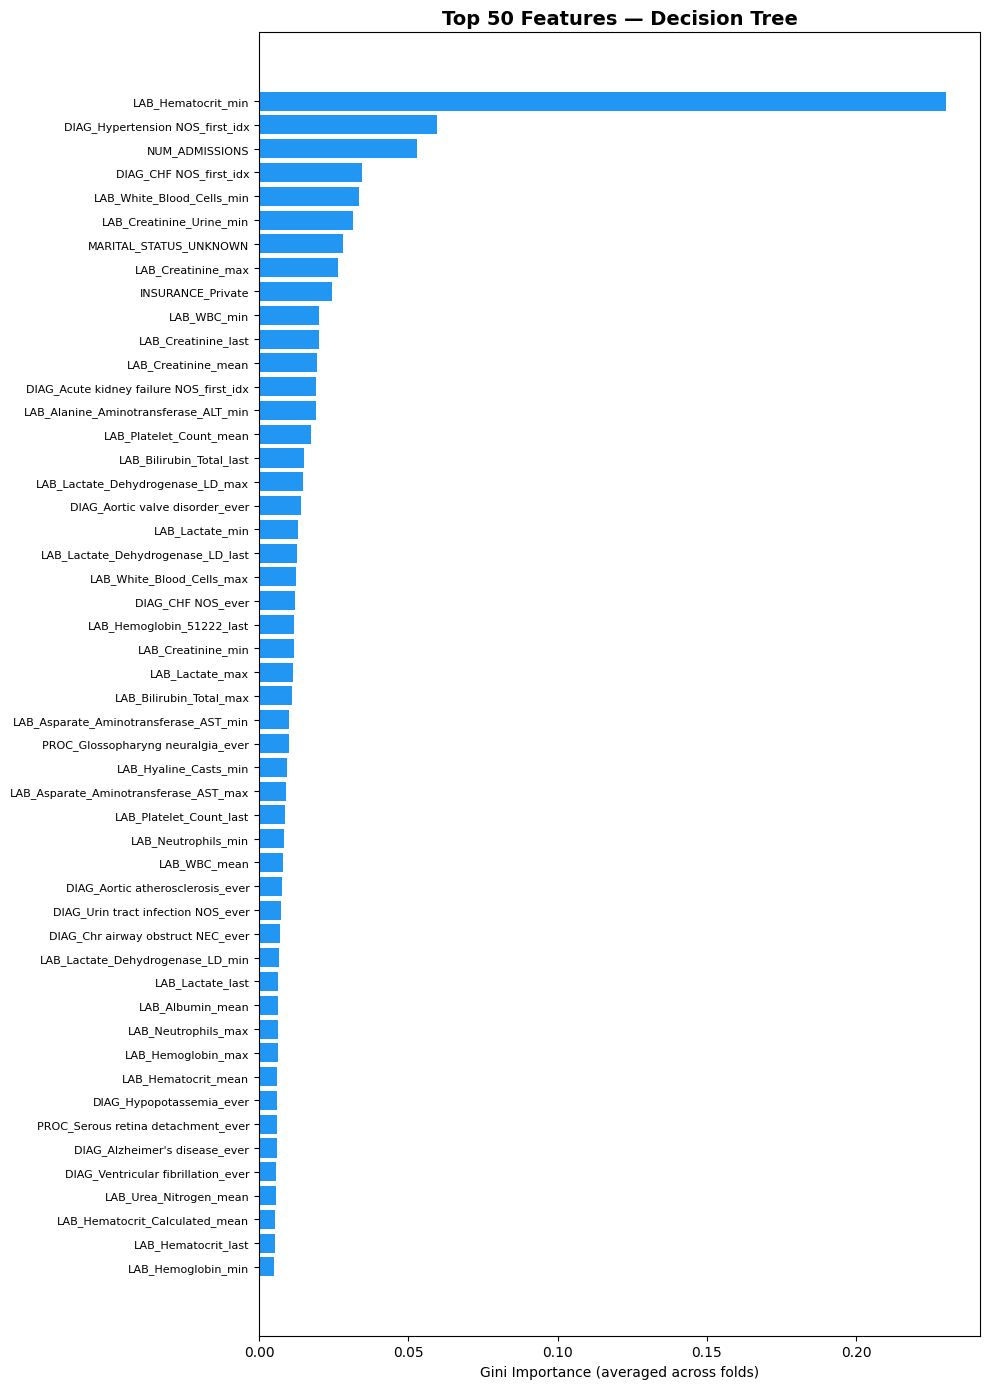

Saved: DT_Top50_Features.png


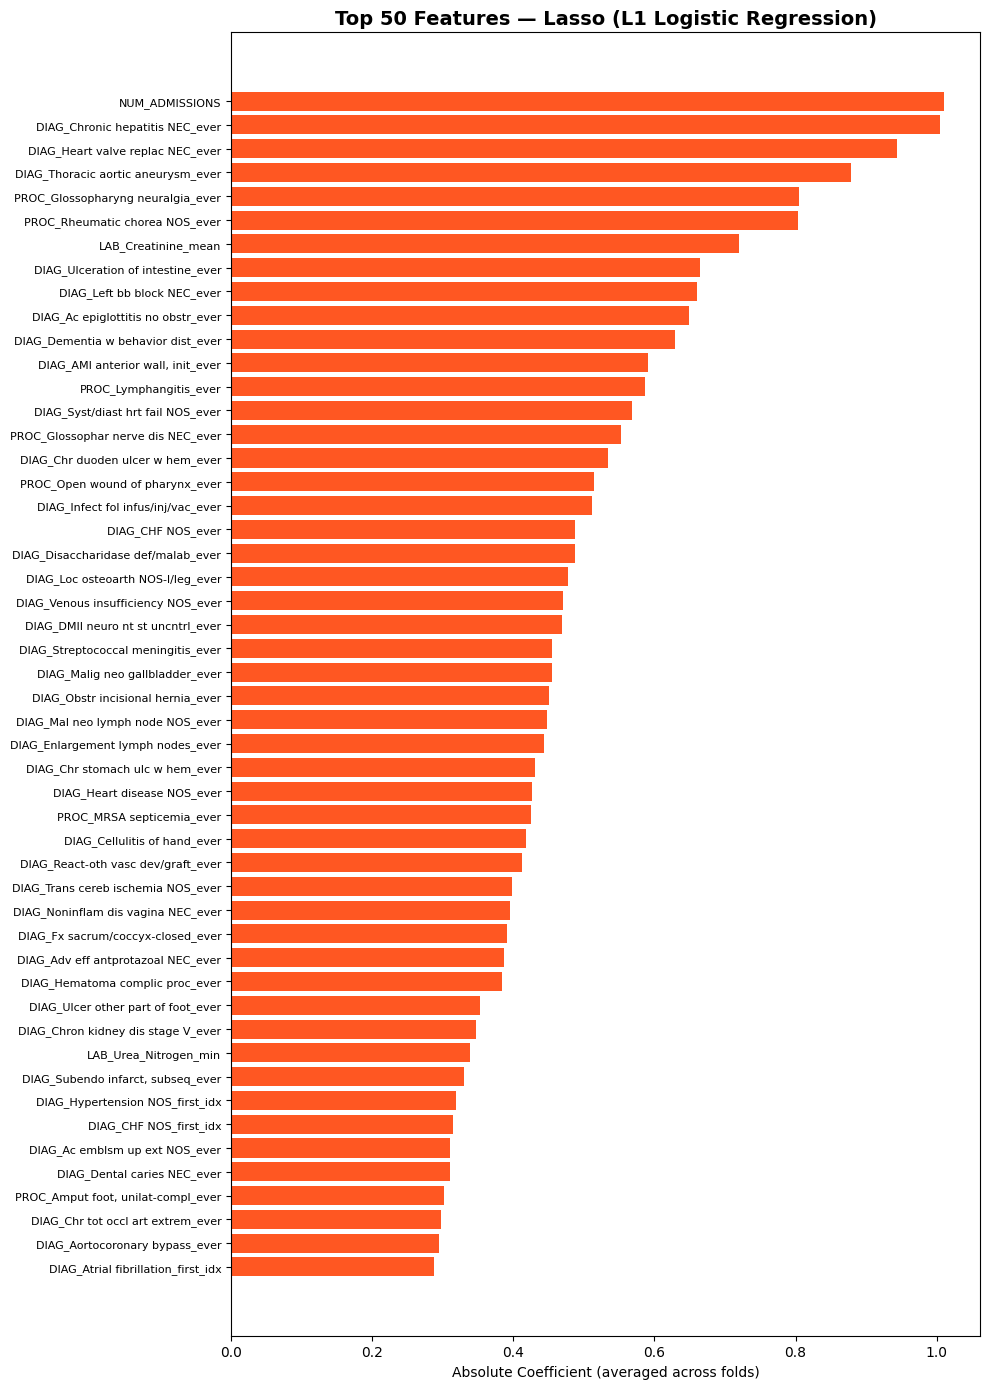

Saved: Lasso_Top50_Features.png


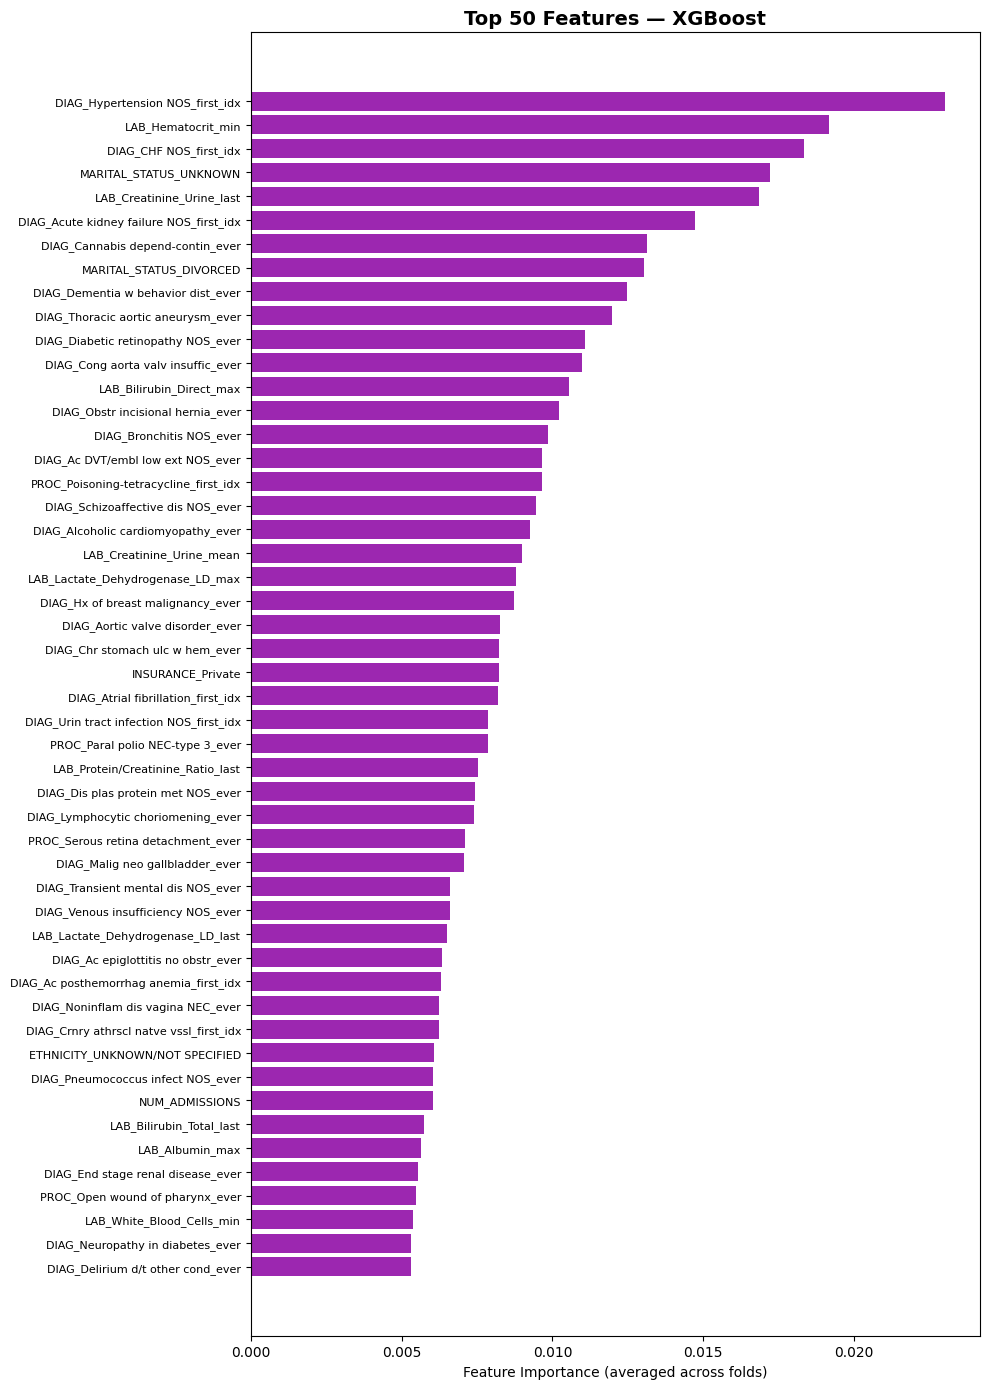

Saved: XGB_Top50_Features.png


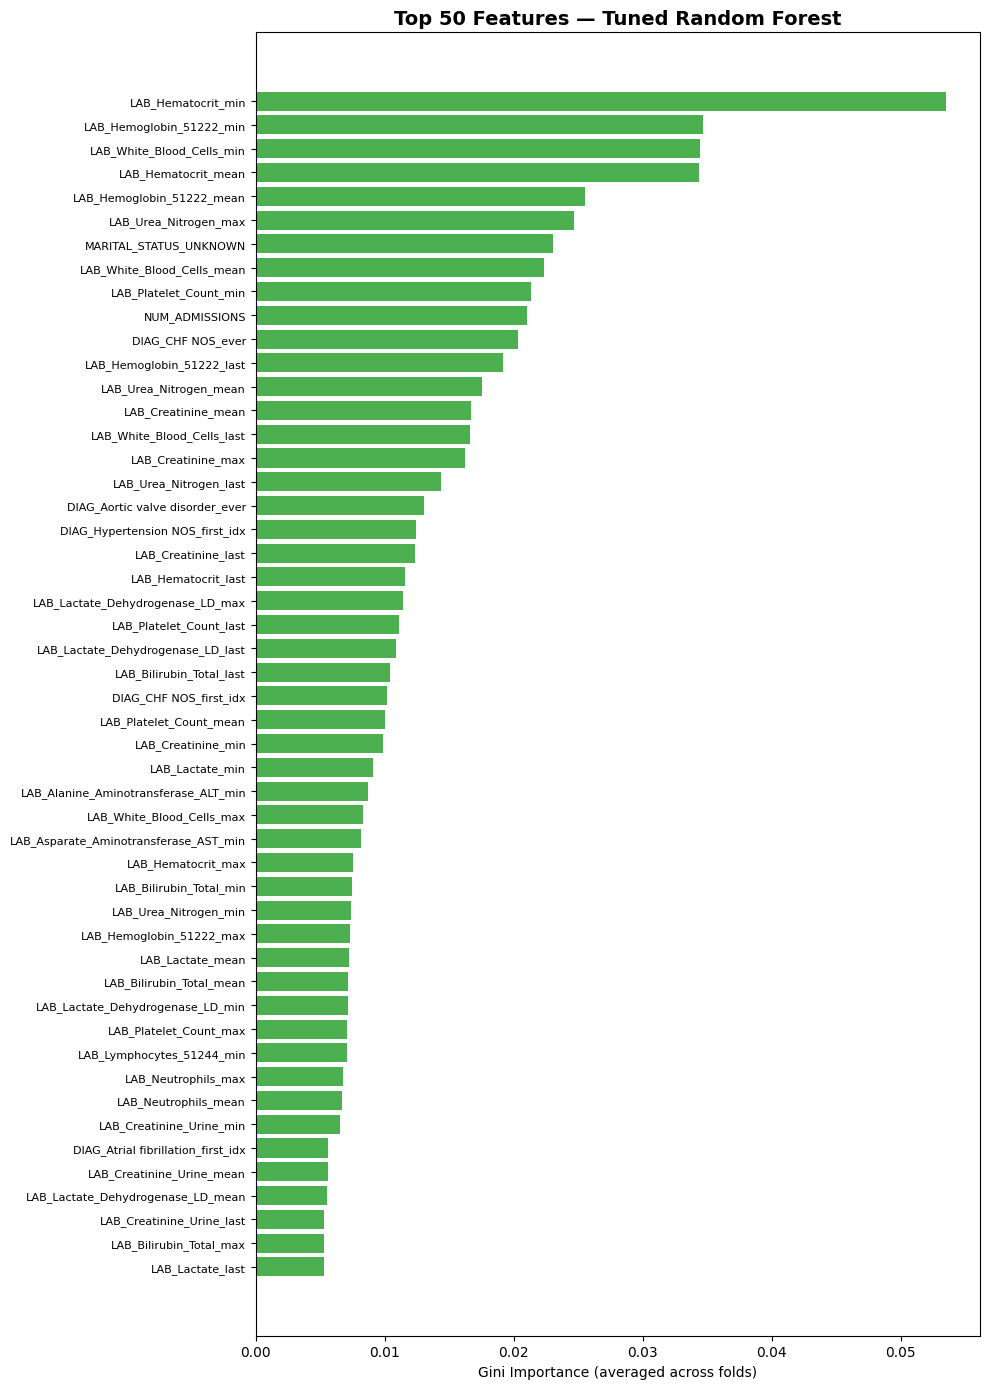

Saved: RF_Tuned_Top50_Features.png


In [12]:
# =============================================================
# FEATURE IMPORTANCE PLOTS
# =============================================================

# Decision Tree
dt_top = dt_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(dt_top['feature'], dt_top['importance'], color='#2196F3')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Decision Tree', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"DT_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: DT_Top50_Features.png")

# Lasso
lasso_top = lasso_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(lasso_top['feature'], lasso_top['importance'], color='#FF5722')
ax.set_xlabel('Absolute Coefficient (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Lasso (L1 Logistic Regression)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"Lasso_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Lasso_Top50_Features.png")

# XGBoost
xgb_top = xgb_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(xgb_top['feature'], xgb_top['importance'], color='#9C27B0')
ax.set_xlabel('Feature Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — XGBoost', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"XGB_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: XGB_Top50_Features.png")

# Tuned Random Forest
rf_top = rf_tuned_importance_df.head(TOP_N).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(rf_top['feature'], rf_top['importance'], color='#4CAF50')
ax.set_xlabel('Gini Importance (averaged across folds)')
ax.set_title(f'Top {TOP_N} Features — Tuned Random Forest', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(r"RF_Tuned_Top50_Features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_Top50_Features.png")

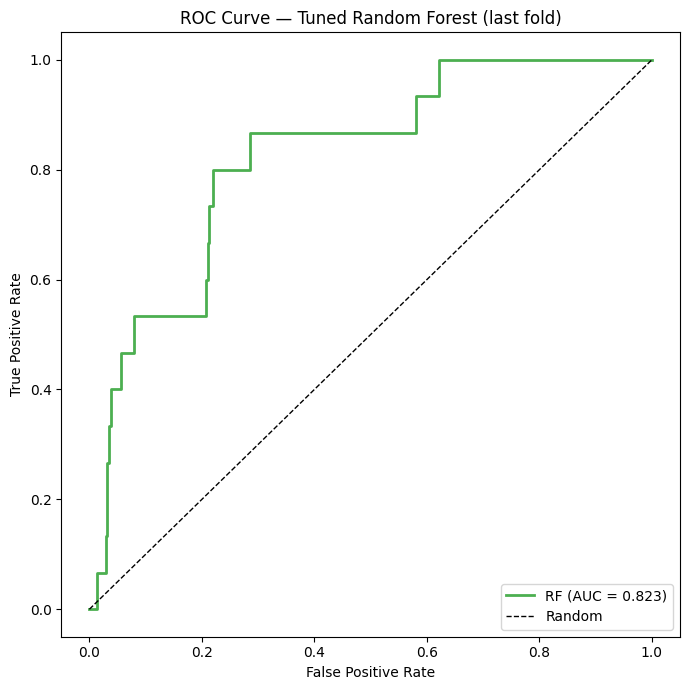

Saved: RF_Tuned_ROC.png


In [13]:
# =============================================================
# ROC CURVE — TUNED RF (last fold)
# =============================================================
last_fold = folds[-1]
rf_last = rf_tuned_estimators[-1]

y_prob_last = rf_last.predict_proba(last_fold['X_test'])[:, 1]
fpr, tpr, _ = roc_curve(last_fold['y_test'], y_prob_last)
auc_val = roc_auc_score(last_fold['y_test'], y_prob_last)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='#4CAF50', lw=2, label=f'RF (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Random Forest (last fold)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"RF_Tuned_ROC.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: RF_Tuned_ROC.png")

In [14]:
# =============================================================
# SAVE ARTIFACTS FOR SHAP (run in separate notebook)
# =============================================================
print("\n" + "=" * 60)
print("SAVING SHAP ARTIFACTS TO DISK")
print("=" * 60)

with open("rf_last_fold_estimator.pkl", "wb") as f:
    pickle.dump(rf_last, f)
print("Saved: rf_last_fold_estimator.pkl")

save_npz("shap_X_test.npz", last_fold['X_test'])
np.save("shap_y_test.npy", last_fold['y_test'])
np.save("shap_feature_cols.npy", np.array(feature_cols))
print("Saved: shap_X_test.npz, shap_y_test.npy, shap_feature_cols.npy")


SAVING SHAP ARTIFACTS TO DISK
Saved: rf_last_fold_estimator.pkl
Saved: shap_X_test.npz, shap_y_test.npy, shap_feature_cols.npy


In [15]:
# =============================================================
# CLASSIFICATION REPORTS (last fold)
# =============================================================
print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS — Last Fold")
print("=" * 60)

# Decision Tree
print("\nDecision Tree:")
dt_pred = dt_estimators[-1].predict(last_fold['X_test'])
print(classification_report(last_fold['y_test'], dt_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], dt_pred))

# Lasso
print("\nLasso:")
lasso_last, scaler_last = lasso_estimators[-1]
X_te_scaled = scaler_last.transform(last_fold['X_test'])
lasso_pred = lasso_last.predict(X_te_scaled)
print(classification_report(last_fold['y_test'], lasso_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], lasso_pred))

# XGBoost
print("\nXGBoost:")
xgb_pred = xgb_estimators[-1].predict(last_fold['X_test'])
print(classification_report(last_fold['y_test'], xgb_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], xgb_pred))

# Tuned RF
print("\nTuned Random Forest:")
rf_pred = rf_last.predict(last_fold['X_test'])
print(classification_report(last_fold['y_test'], rf_pred, target_names=['Control', 'Disease']))
print("Confusion Matrix:")
print(confusion_matrix(last_fold['y_test'], rf_pred))


CLASSIFICATION REPORTS — Last Fold

Decision Tree:
              precision    recall  f1-score   support

     Control       1.00      0.85      0.92     45173
     Disease       0.00      0.53      0.00        15

    accuracy                           0.85     45188
   macro avg       0.50      0.69      0.46     45188
weighted avg       1.00      0.85      0.92     45188

Confusion Matrix:
[[38217  6956]
 [    7     8]]

Lasso:
              precision    recall  f1-score   support

     Control       1.00      0.95      0.97     45173
     Disease       0.00      0.47      0.01        15

    accuracy                           0.95     45188
   macro avg       0.50      0.71      0.49     45188
weighted avg       1.00      0.95      0.97     45188

Confusion Matrix:
[[42941  2232]
 [    8     7]]

XGBoost:
              precision    recall  f1-score   support

     Control       1.00      0.99      1.00     45173
     Disease       0.01      0.13      0.01        15

    accuracy  

In [16]:
# =============================================================
# FEATURE OVERLAP ANALYSIS
# =============================================================
print("\n" + "=" * 60)
print("FEATURE OVERLAP ANALYSIS")
print("=" * 60)

dt_top50_set = set(dt_importance_df.head(TOP_N)['feature'])
lasso_top50_set = set(lasso_importance_df.head(TOP_N)['feature'])
xgb_top50_set = set(xgb_importance_df.head(TOP_N)['feature'])
rf_top50_set = set(rf_tuned_importance_df.head(TOP_N)['feature'])

overlap_dt_lasso = dt_top50_set & lasso_top50_set
print(f"\nDT vs Lasso top {TOP_N}:")
print(f"  Shared: {len(overlap_dt_lasso)}")
print(f"  Only DT: {len(dt_top50_set - lasso_top50_set)}")
print(f"  Only Lasso: {len(lasso_top50_set - dt_top50_set)}")

overlap_rf_lasso = rf_top50_set & lasso_top50_set
print(f"\nRF vs Lasso top {TOP_N}:")
print(f"  Shared: {len(overlap_rf_lasso)}")
print(f"  Only RF: {len(rf_top50_set - lasso_top50_set)}")
print(f"  Only Lasso: {len(lasso_top50_set - rf_top50_set)}")

overlap_xgb_rf = xgb_top50_set & rf_top50_set
print(f"\nXGBoost vs RF top {TOP_N}:")
print(f"  Shared: {len(overlap_xgb_rf)}")
print(f"  Only XGBoost: {len(xgb_top50_set - rf_top50_set)}")
print(f"  Only RF: {len(rf_top50_set - xgb_top50_set)}")

overlap_all = dt_top50_set & lasso_top50_set & xgb_top50_set & rf_top50_set
print(f"\nAll four models top {TOP_N}:")
print(f"  Shared by all: {len(overlap_all)}")
for f in sorted(overlap_all):
    print(f"    {f}")

dt_importance_df.to_csv(r"DT_Feature_Importances.csv", index=False)
lasso_importance_df.to_csv(r"Lasso_Feature_Importances.csv", index=False)
xgb_importance_df.to_csv(r"XGB_Feature_Importances.csv", index=False)
rf_tuned_importance_df.to_csv(r"RF_Tuned_Feature_Importances.csv", index=False)
print("\nSaved all importance CSVs.")


FEATURE OVERLAP ANALYSIS

DT vs Lasso top 50:
  Shared: 6
  Only DT: 44
  Only Lasso: 44

RF vs Lasso top 50:
  Shared: 7
  Only RF: 43
  Only Lasso: 43

XGBoost vs RF top 50:
  Shared: 13
  Only XGBoost: 37
  Only RF: 37

All four models top 50:
  Shared by all: 3
    DIAG_CHF NOS_first_idx
    DIAG_Hypertension NOS_first_idx
    NUM_ADMISSIONS

Saved all importance CSVs.
